<a href="https://colab.research.google.com/github/Geethanjali295/ML-PROJECT/blob/main/DAY_6_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#UNSUPERVISED LEARNING AND kMEANS CLUSTER
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [ ]:
url=pd.read_csv("https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv")
url

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [ ]:
url.shape

(200, 5)

In [ ]:
url.size

1000

In [ ]:
url.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
url.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


<Axes: >

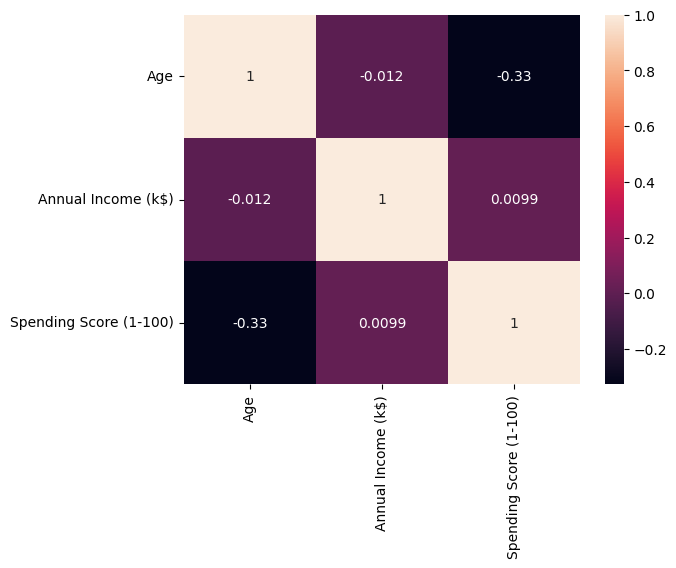

In [ ]:
data=url.drop(columns=['CustomerID','Gender'])
sns.heatmap(data.corr(),annot=True)

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

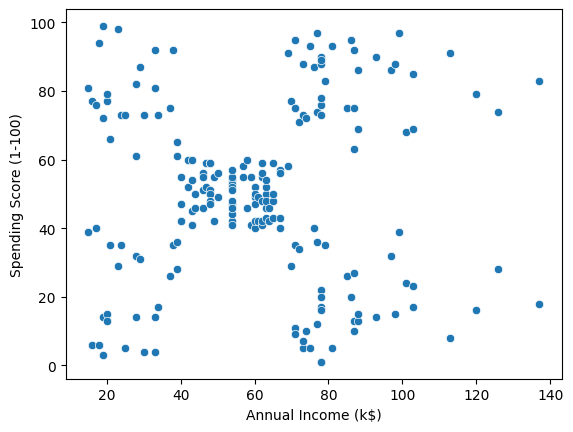

In [ ]:
sns.scatterplot(data=url,x='Annual Income (k$)',y='Spending Score (1-100)')

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(data.drop(columns=['Age']))
x_scaled

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
wcss=[]
sil_scores=[]
for k in range(2,11):      #2 to 10 cluster
  kmeans=KMeans(n_clusters=k,random_state=42,init='k-means++',max_iter=300,n_init=10)
  kmeans.fit_predict(x_scaled)
  labels=kmeans.labels_
  wcss.append(kmeans.inertia_)
  sil_h=silhouette_score(x_scaled,labels)
  sil_scores.append(sil_h)


In [ ]:
for i ,k in enumerate(range(2,11)):
  print(f'for k={k},wcss={wcss[i]:.2f} and sil_score={sil_scores[i]:.2f}')

for k=2,wcss=269.69 and sil_score=0.32
for k=3,wcss=157.70 and sil_score=0.47
for k=4,wcss=108.92 and sil_score=0.49
for k=5,wcss=65.57 and sil_score=0.55
for k=6,wcss=55.06 and sil_score=0.54
for k=7,wcss=44.86 and sil_score=0.53
for k=8,wcss=37.23 and sil_score=0.46
for k=9,wcss=32.39 and sil_score=0.46
for k=10,wcss=29.98 and sil_score=0.44


Text(0, 0.5, 'silhoutte score')

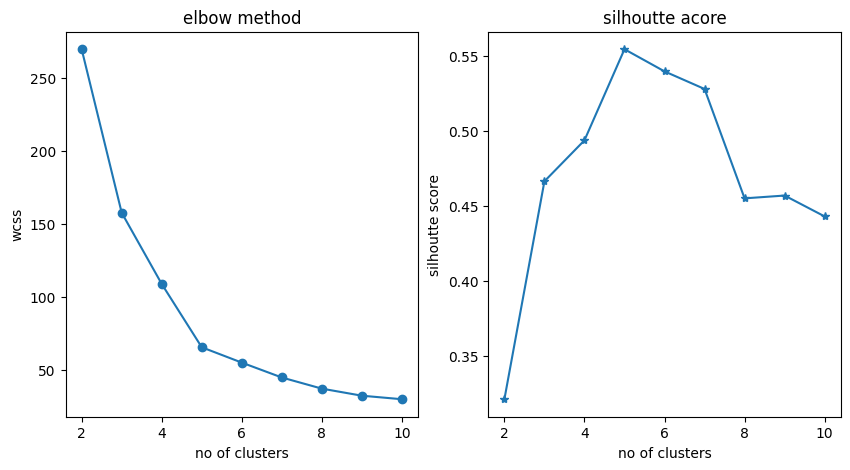

In [ ]:

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(range(2,11),wcss,marker='o')
plt.title("elbow method")
plt.xlabel("no of clusters")
plt.ylabel("wcss")

plt.subplot(1,2,2)
plt.plot(range(2,11),sil_scores,marker='*')
plt.title("silhoutte acore")
plt.xlabel("no of clusters")
plt.ylabel("silhoutte score")


In [ ]:
 kmeans=KMeans(n_clusters=5,random_state=42,init='k-means++',max_iter=300,n_init=10)
 kmeans.fit(x_scaled)
 cluster_labels=kmeans.predict(x_scaled)
 cluster_labels

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [ ]:
url['k_means_cluster']=cluster_labels
url.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),k_means_cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [ ]:
url['k_means_cluster'].value_counts()

,count
k_means_cluster,
0,81
1,39
3,35
4,23
2,22


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

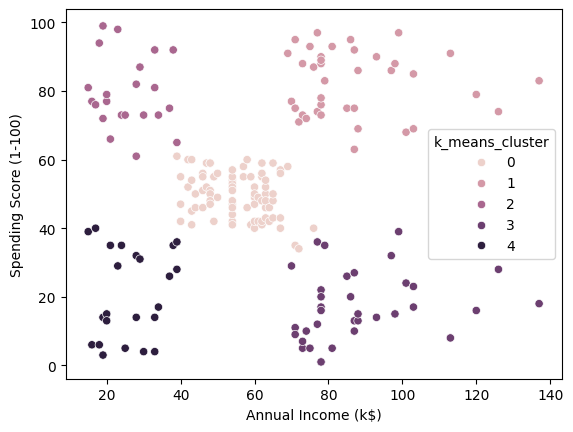

In [ ]:
sns.scatterplot(data=url,x='Annual Income (k$)',y='Spending Score (1-100)',hue='k_means_cluster')

<Axes: xlabel='Age', ylabel='Spending Score (1-100)'>

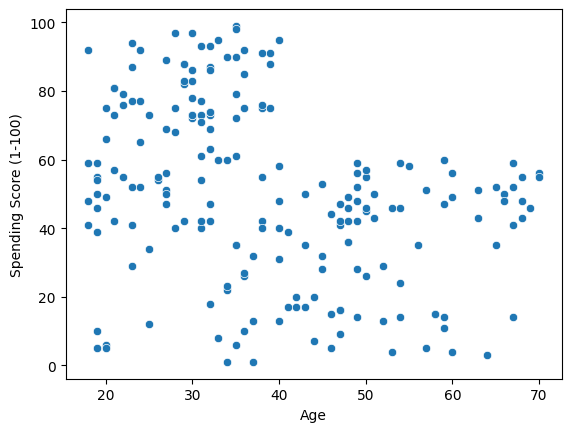

In [ ]:
sns.scatterplot(data=url,x='Age',y='Spending Score (1-100)') #for comparison

<Axes: xlabel='Age', ylabel='Spending Score (1-100)'>

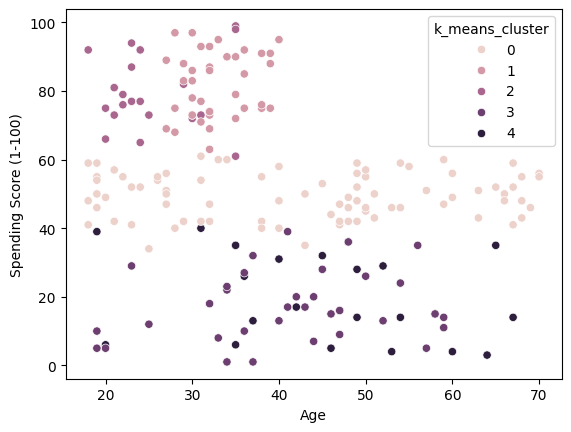

In [ ]:
sns.scatterplot(data=url,x='Age',y='Spending Score (1-100)',hue='k_means_cluster')

In [ ]:
new_customer=np.array([[45,60]])
scaled=scaler.transform(new_customer)
cluster=kmeans.predict(scaled)
cluster


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([0], dtype=int32)

In [ ]:
#AGGROMELATIVE AND HIERARCHICAL CLUSTERING
from scipy.cluster.hierarchy import linkage,dendrogram

{'icoord': [[15.0, 15.0, 25.0, 25.0],
  [5.0, 5.0, 20.0, 20.0],
  [75.0, 75.0, 85.0, 85.0],
  [65.0, 65.0, 80.0, 80.0],
  [55.0, 55.0, 72.5, 72.5],
  [45.0, 45.0, 63.75, 63.75],
  [35.0, 35.0, 54.375, 54.375],
  [12.5, 12.5, 44.6875, 44.6875],
  [105.0, 105.0, 115.0, 115.0],
  [95.0, 95.0, 110.0, 110.0],
  [145.0, 145.0, 155.0, 155.0],
  [135.0, 135.0, 150.0, 150.0],
  [165.0, 165.0, 175.0, 175.0],
  [142.5, 142.5, 170.0, 170.0],
  [125.0, 125.0, 156.25, 156.25],
  [185.0, 185.0, 195.0, 195.0],
  [215.0, 215.0, 225.0, 225.0],
  [205.0, 205.0, 220.0, 220.0],
  [190.0, 190.0, 212.5, 212.5],
  [140.625, 140.625, 201.25, 201.25],
  [102.5, 102.5, 170.9375, 170.9375],
  [235.0, 235.0, 245.0, 245.0],
  [255.0, 255.0, 265.0, 265.0],
  [240.0, 240.0, 260.0, 260.0],
  [285.0, 285.0, 295.0, 295.0],
  [275.0, 275.0, 290.0, 290.0],
  [315.0, 315.0, 325.0, 325.0],
  [305.0, 305.0, 320.0, 320.0],
  [282.5, 282.5, 312.5, 312.5],
  [250.0, 250.0, 297.5, 297.5],
  [335.0, 335.0, 345.0, 345.0],
  [355.0

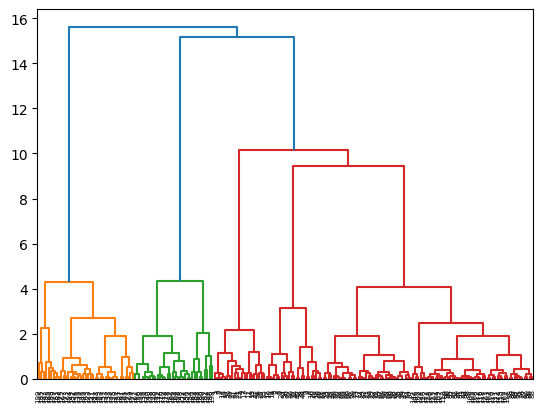

In [ ]:
mergings=linkage(x_scaled,method='ward')
dendrogram(mergings)


In [ ]:
from sklearn.cluster import AgglomerativeClustering
agg_hc=AgglomerativeClustering(n_clusters=5,metric='euclidean',linkage='ward')
agg_cluster=agg_hc.fit_predict(x_scaled)
agg_cluster

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 2,
       4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 1, 0, 1, 0, 1,
       2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1])

In [ ]:
url['agg_cluster']=agg_cluster
url.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),k_means_cluster,agg_cluster
0,1,Male,19,15,39,4,4
1,2,Male,21,15,81,2,3
2,3,Female,20,16,6,4,4
3,4,Female,23,16,77,2,3
4,5,Female,31,17,40,4,4


In [ ]:
url.k_means_cluster.value_counts()

,count
k_means_cluster,
0,81
1,39
3,35
4,23
2,22


In [ ]:
url['agg_cluster'].value_counts()

,count
agg_cluster,
2,85
1,39
0,32
4,23
3,21


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

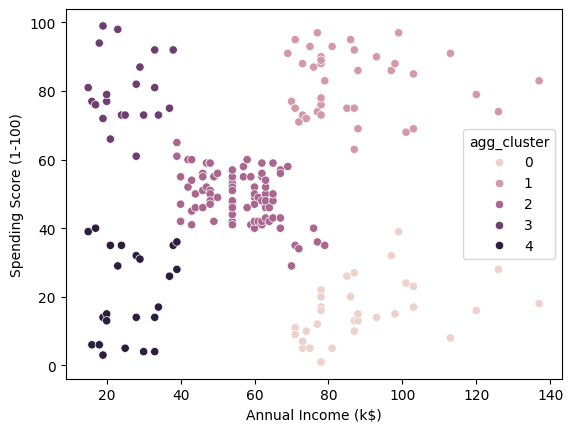

In [ ]:
sns.scatterplot(data=url,x='Annual Income (k$)',y='Spending Score (1-100)',hue='agg_cluster')

In [ ]:
sil_scores={}
for i in range(2,11):
  agg_hc=AgglomerativeClustering(n_clusters=5,metric='euclidean',linkage='ward')
  sil_h=silhouette_score(x_scaled,agg_hc.fit_predict(x_scaled))
  sil_scores[i]=(sil_h)
sil_scores


{2: np.float64(0.5538089226688662),
 3: np.float64(0.5538089226688662),
 4: np.float64(0.5538089226688662),
 5: np.float64(0.5538089226688662),
 6: np.float64(0.5538089226688662),
 7: np.float64(0.5538089226688662),
 8: np.float64(0.5538089226688662),
 9: np.float64(0.5538089226688662),
 10: np.float64(0.5538089226688662)}

In [ ]:
from sklearn.cluster import DBSCAN

In [ ]:
db = DBSCAN(eps=0.3, min_samples=10)
db_cluster_labels=db.fit_predict(x_scaled)
db_cluster_labels

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1,  0, -1,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  3, -1,  1,  0,  3,  2,  1,  2,  1, -1,  1,  2,  3,
        2,  1,  2,  1,  2,  3, -1,  3,  2,  3, -1,  1, -1,  3, -1,  3, -1,
        1, -1,  3,  2,  1,  2,  1, -1,  1,  2,  3, -1,  1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [ ]:
url['db_cluster']=db_cluster_labels
url.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),k_means_cluster,agg_cluster,db_cluster
0,1,Male,19,15,39,4,4,-1
1,2,Male,21,15,81,2,3,-1
2,3,Female,20,16,6,4,4,-1
3,4,Female,23,16,77,2,3,-1
4,5,Female,31,17,40,4,4,-1


In [ ]:
url['db_cluster'].value_counts()

,count
db_cluster,
-1,88
0,80
1,12
3,10
2,10


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

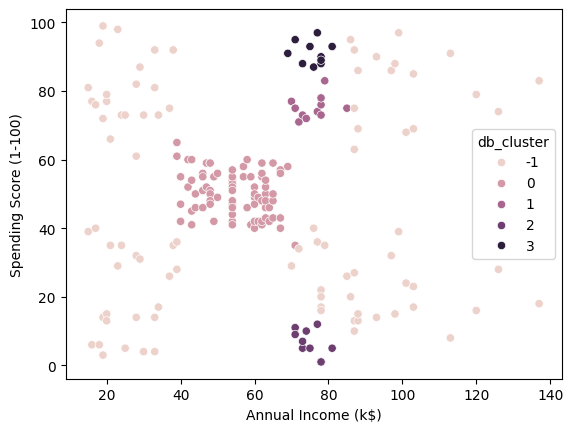

In [ ]:
sns.scatterplot(data=url,x='Annual Income (k$)',y='Spending Score (1-100)',hue='db_cluster')

In [ ]:
sil_scores={}
for i in range(2,11):
  db_hc=DBSCAN()
  sil_h=silhouette_score(x_scaled,db_hc.fit_predict(x_scaled))
  sil_scores[i]=(sil_h)
sil_scores


{2: np.float64(0.35044619989666004),
 3: np.float64(0.35044619989666004),
 4: np.float64(0.35044619989666004),
 5: np.float64(0.35044619989666004),
 6: np.float64(0.35044619989666004),
 7: np.float64(0.35044619989666004),
 8: np.float64(0.35044619989666004),
 9: np.float64(0.35044619989666004),
 10: np.float64(0.35044619989666004)}

In [ ]:
from scipy.cluster.hierarchy import fcluster
cluster_labels=fcluster(mergings,criterion='maxclust',t=5)
cluster_labels

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 5,
       4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 1, 5, 1, 5, 1, 2, 1, 2, 1,
       5, 1, 2, 1, 2, 1, 2, 1, 2, 1, 5, 1, 2, 1, 5, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 5, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1], dtype=int32)

In [ ]:
fish=pd.read_csv('/content/fish (2) (1).csv')
fish

,Bream,242.0,23.2,25.4,30.0,38.4,13.4
0,Bream,290.0,24.0,26.3,31.2,40.0,13.8
1,Bream,340.0,23.9,26.5,31.1,39.8,15.1
2,Bream,363.0,26.3,29.0,33.5,38.0,13.3
3,Bream,430.0,26.5,29.0,34.0,36.6,15.1
4,Bream,450.0,26.8,29.7,34.7,39.2,14.2
...,...,...,...,...,...,...,...
79,Pike,950.0,48.3,51.7,55.1,16.2,11.2
80,Pike,1250.0,52.0,56.0,59.7,17.9,11.7
81,Pike,1600.0,56.0,60.0,64.0,15.0,9.6
82,Pike,1550.0,56.0,60.0,64.0,15.0,9.6


In [ ]:
fish.columns=['Species','weigtht','length1','length2','length3','height','width']
fish.columns

Index(['Species', 'weigtht', 'length1', 'length2', 'length3', 'height',
       'width'],
      dtype='object')

In [ ]:
fish.head()

,Species,weigtht,length1,length2,length3,height,width
0,Bream,290.0,24.0,26.3,31.2,40.0,13.8
1,Bream,340.0,23.9,26.5,31.1,39.8,15.1
2,Bream,363.0,26.3,29.0,33.5,38.0,13.3
3,Bream,430.0,26.5,29.0,34.0,36.6,15.1
4,Bream,450.0,26.8,29.7,34.7,39.2,14.2


In [ ]:
fish.describe()

,weigtht,length1,length2,length3,height,width
count,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000
mean,434.017857,27.388095,29.607143,33.157143,27.953571,12.859524
std,382.648669,11.348058,12.249630,13.272086,10.351142,2.129377
min,0.000000,9.300000,9.800000,10.800000,14.500000,8.700000
25%,120.000000,19.325000,20.950000,23.550000,16.875000,10.875000
50%,390.000000,28.450000,30.850000,35.050000,26.900000,13.700000
75%,657.500000,32.725000,36.000000,40.675000,39.225000,14.700000
max,1650.000000,59.000000,63.400000,68.000000,44.500000,16.100000


In [ ]:
fish.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  84 non-null     object 
 1   weigtht  84 non-null     float64
 2   length1  84 non-null     float64
 3   length2  84 non-null     float64
 4   length3  84 non-null     float64
 5   height   84 non-null     float64
 6   width    84 non-null     float64
dtypes: float64(6), object(1)
memory usage: 4.7+ KB


<Axes: >

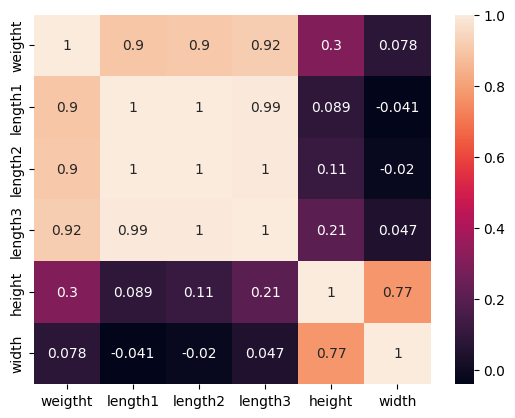

In [ ]:
data=fish.drop(columns=['Species'])
sns.heatmap(data.corr(),annot=True)

In [ ]:
data

,weigtht,length1,length2,length3,height,width
0,290.0,24.0,26.3,31.2,40.0,13.8
1,340.0,23.9,26.5,31.1,39.8,15.1
2,363.0,26.3,29.0,33.5,38.0,13.3
3,430.0,26.5,29.0,34.0,36.6,15.1
4,450.0,26.8,29.7,34.7,39.2,14.2
...,...,...,...,...,...,...
79,950.0,48.3,51.7,55.1,16.2,11.2
80,1250.0,52.0,56.0,59.7,17.9,11.7
81,1600.0,56.0,60.0,64.0,15.0,9.6
82,1550.0,56.0,60.0,64.0,15.0,9.6


<Axes: xlabel='length1', ylabel='weigtht'>

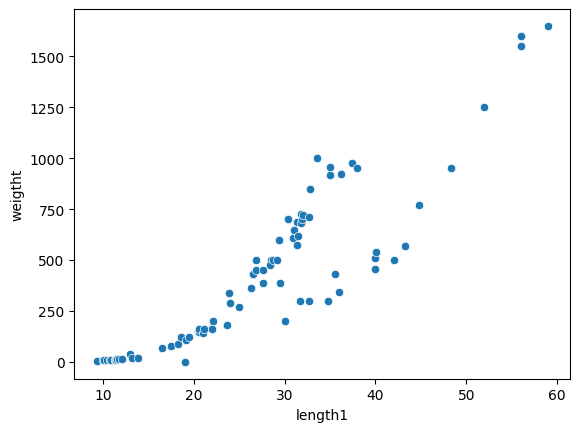

In [ ]:
sns.scatterplot(data=data,x='length1',y='weigtht')

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(data)
x_scaled

array([[-0.37863149, -0.30035487, -0.2716005 , -0.14834877,  1.1707675 ,
         0.44432002],
       [-0.24717853, -0.30921988, -0.25517542, -0.15592863,  1.15132991,
         1.05849403],
       [-0.18671016, -0.09645972, -0.04986186,  0.02598811,  0.97639163,
         0.20809925],
       [-0.01056318, -0.0787297 , -0.04986186,  0.06388743,  0.84032853,
         1.05849403],
       [ 0.042018  , -0.05213468,  0.00762593,  0.11694647,  1.09301715,
         0.63329664],
       [ 0.17347097, -0.05213468,  0.00762593,  0.10178675,  1.27767423,
         1.15298234],
       [-0.11572556,  0.01878537,  0.03226356,  0.13968607,  0.80145335,
         0.25534341],
       [ 0.042018  ,  0.01878537,  0.03226356,  0.14726593,  1.16104871,
         0.44432002],
       [ 0.17347097,  0.09857043,  0.08975135,  0.23064443,  1.10273595,
         0.39707587],
       [ 0.10774449,  0.08970542,  0.11438898,  0.23064443,  1.11245474,
         0.58605249],
       [ 0.17347097,  0.11630044,  0.11438898,  0.

In [ ]:
data

,weigtht,length1,length2,length3,height,width
0,290.0,24.0,26.3,31.2,40.0,13.8
1,340.0,23.9,26.5,31.1,39.8,15.1
2,363.0,26.3,29.0,33.5,38.0,13.3
3,430.0,26.5,29.0,34.0,36.6,15.1
4,450.0,26.8,29.7,34.7,39.2,14.2
...,...,...,...,...,...,...
79,950.0,48.3,51.7,55.1,16.2,11.2
80,1250.0,52.0,56.0,59.7,17.9,11.7
81,1600.0,56.0,60.0,64.0,15.0,9.6
82,1550.0,56.0,60.0,64.0,15.0,9.6


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
wcss=[]
sil_scores=[]
for k in range(2,11):      #2 to 10 cluster
  kmeans=KMeans(n_clusters=k,random_state=42,init='k-means++',max_iter=300,n_init=10)
  kmeans.fit_predict(x_scaled)
  labels=kmeans.labels_
  wcss.append(kmeans.inertia_)
  sil_h=silhouette_score(x_scaled,labels)
  sil_scores.append(sil_h)


In [ ]:
for i ,k in enumerate(range(2,11)):
  print(f'for k={k},wcss={wcss[i]:.2f} and sil_score={sil_scores[i]:.2f}')

for k=2,wcss=280.89 and sil_score=0.42
for k=3,wcss=152.52 and sil_score=0.52
for k=4,wcss=95.64 and sil_score=0.57
for k=5,wcss=50.03 and sil_score=0.61
for k=6,wcss=37.64 and sil_score=0.53
for k=7,wcss=31.31 and sil_score=0.51
for k=8,wcss=26.62 and sil_score=0.50
for k=9,wcss=22.88 and sil_score=0.45
for k=10,wcss=19.87 and sil_score=0.45


Text(0, 0.5, 'silhoutte score')

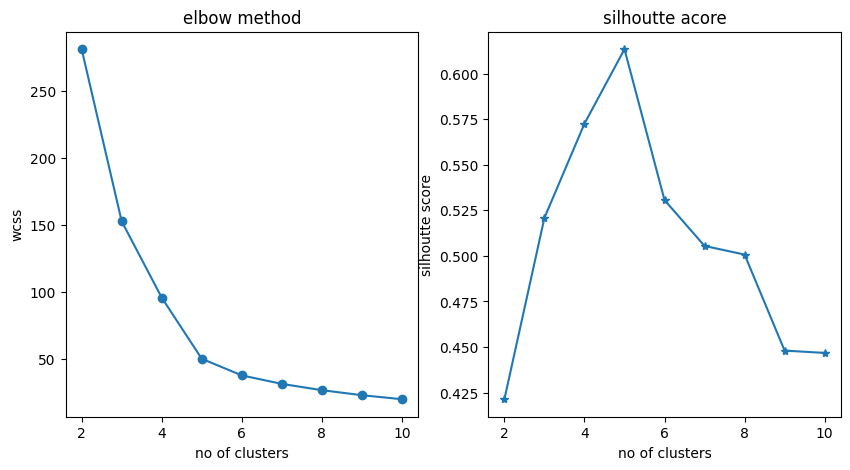

In [ ]:

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(range(2,11),wcss,marker='o')
plt.title("elbow method")
plt.xlabel("no of clusters")
plt.ylabel("wcss")

plt.subplot(1,2,2)
plt.plot(range(2,11),sil_scores,marker='*')
plt.title("silhoutte acore")
plt.xlabel("no of clusters")
plt.ylabel("silhoutte score")


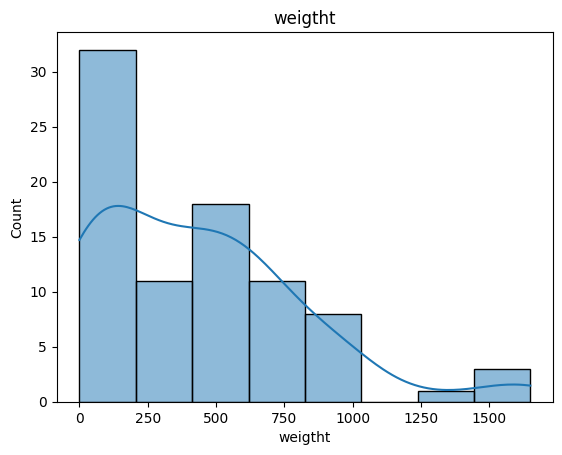

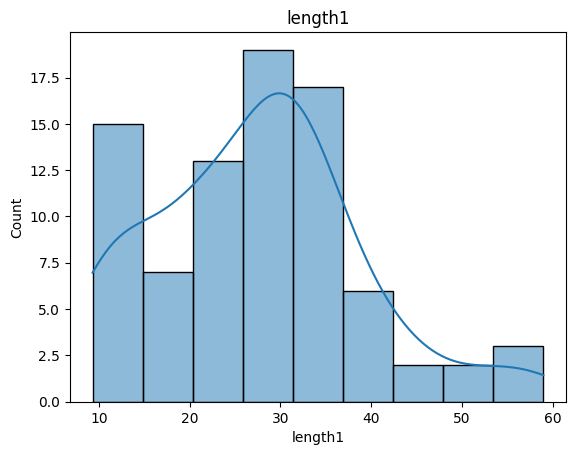

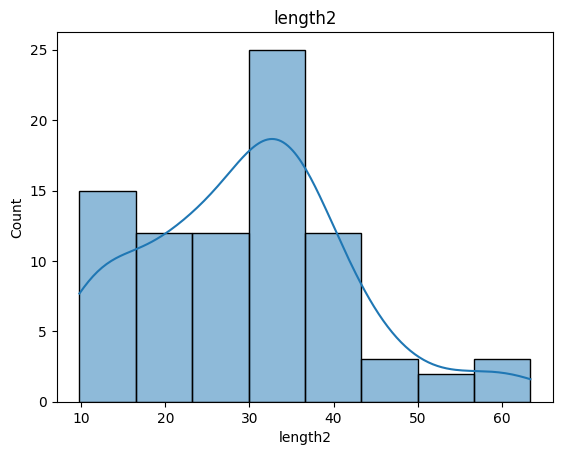

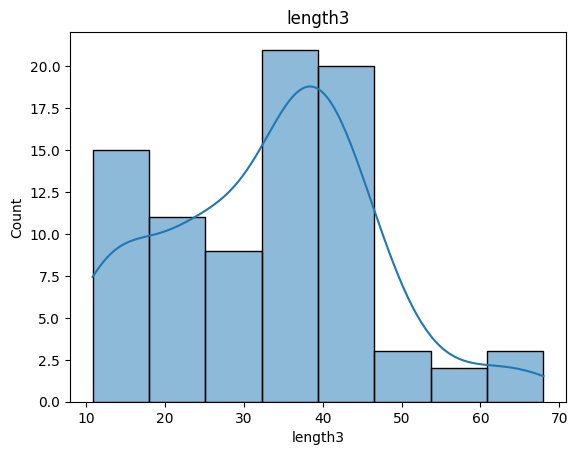

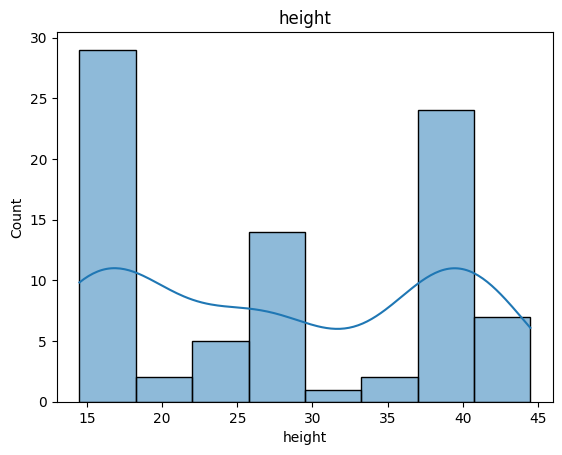

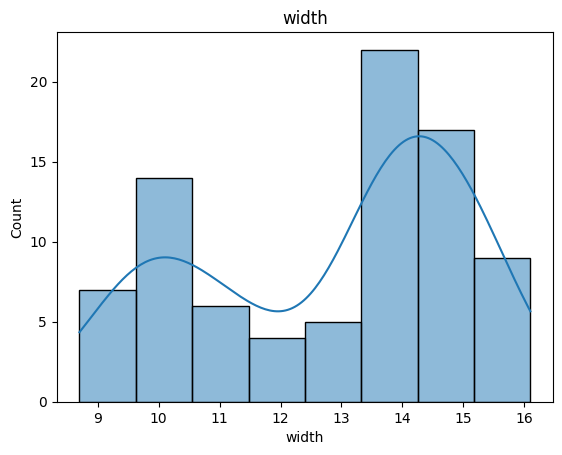

In [ ]:
numerical_cols=fish.select_dtypes(include=np.number).columns
numerical_cols
for col in numerical_cols:
  sns.histplot(data[col],kde=True)
  plt.title(col)
  plt.show()

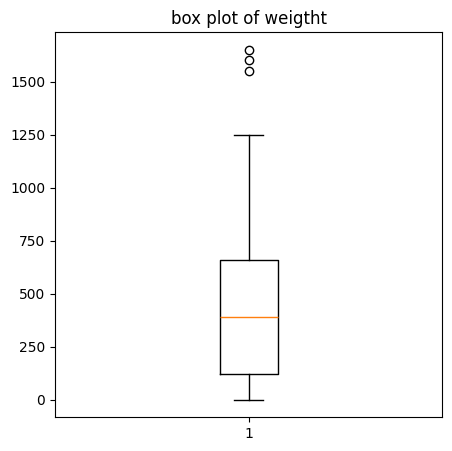

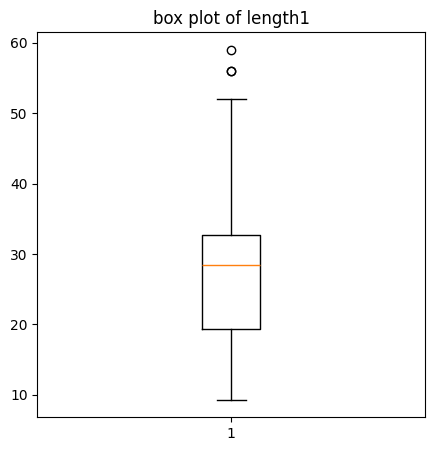

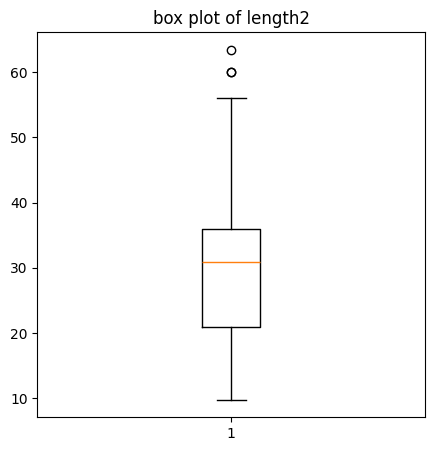

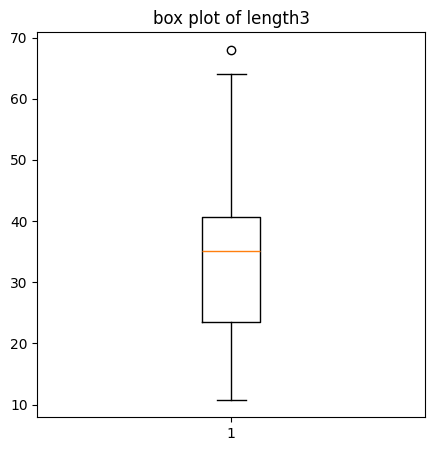

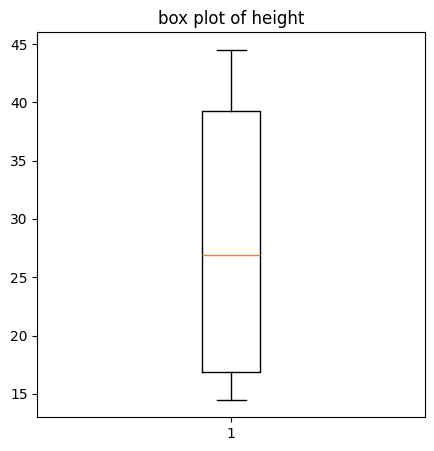

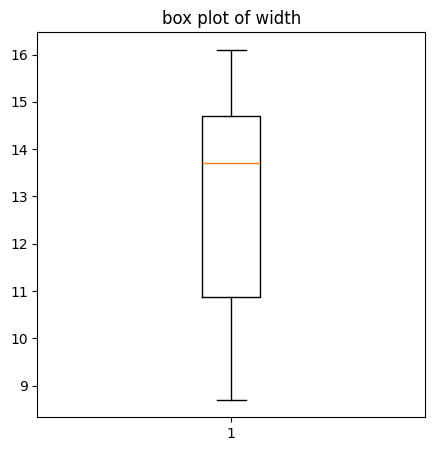

In [ ]:
numerical_cols=fish.select_dtypes(include=np.number).columns
numerical_cols
for col in numerical_cols:
  plt.figure(figsize=(5,5))
  plt.boxplot(data[col])
  plt.title(f'box plot of {col}')
  plt.show()

In [ ]:
from scipy.stats import skew
skew_values=fish[numerical_cols].skew()
print(skew_values)

weigtht    1.093594
length1    0.485725
length2    0.418112
length3    0.162470
height     0.055153
width     -0.494233
dtype: float64


In [ ]:
from scipy.stats.mstats import winsorize
data['weigtht']=winsorize(data['weigtht'],limits=(0.05,0.05))
print("outliers in 'weigtht' column treated using winsorization method (5th and 95th percentile)")
data.head()

outliers in 'weigtht' column treated using winsorization method (5th and 95th percentile)


,weigtht,length1,length2,length3,height,width
0,290.0,24.0,26.3,31.2,40.0,13.8
1,340.0,23.9,26.5,31.1,39.8,15.1
2,363.0,26.3,29.0,33.5,38.0,13.3
3,430.0,26.5,29.0,34.0,36.6,15.1
4,450.0,26.8,29.7,34.7,39.2,14.2


<Axes: ylabel='weigtht'>

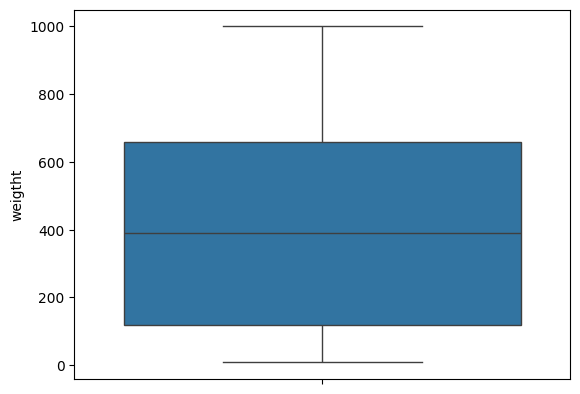

In [ ]:
sns.boxplot(y=fish['weigtht'])

In [ ]:
fish['weigtht'].max()

1000.0

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
wcss=[]
sil_scores=[]
for k in range(2,11):      #2 to 10 cluster
  kmeans=KMeans(n_clusters=k,random_state=42,init='k-means++',max_iter=300,n_init=10)
  kmeans.fit_predict(x_scaled)
  labels=kmeans.labels_
  wcss.append(kmeans.inertia_)
  sil_h=silhouette_score(x_scaled,labels)
  sil_scores.append(sil_h)

In [ ]:
kmeans=KMeans(n_clusters=5,random_state=42,init='k-means++',max_iter=300,n_init=10)
kmeans.fit(x_scaled)
cluster_labels=kmeans.predict(x_scaled)
cluster_labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3,
       1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 4, 4], dtype=int32)

In [ ]:
fish['k_means_cluster']=cluster_labels
fish.head()

,Species,weigtht,length1,length2,length3,height,width,k_means_cluster
0,Bream,290.0,24.0,26.3,31.2,40.0,13.8,0
1,Bream,340.0,23.9,26.5,31.1,39.8,15.1,0
2,Bream,363.0,26.3,29.0,33.5,38.0,13.3,0
3,Bream,430.0,26.5,29.0,34.0,36.6,15.1,0
4,Bream,450.0,26.8,29.7,34.7,39.2,14.2,0


<Axes: xlabel='weigtht', ylabel='length1'>

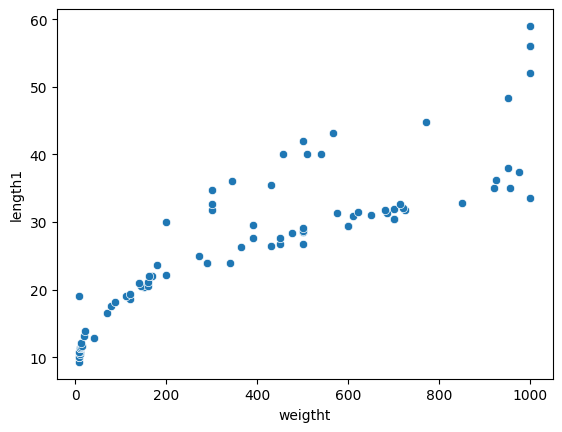

In [ ]:
sns.scatterplot(data=fish,x='weigtht',y='length1')

<Axes: xlabel='weigtht', ylabel='length1'>

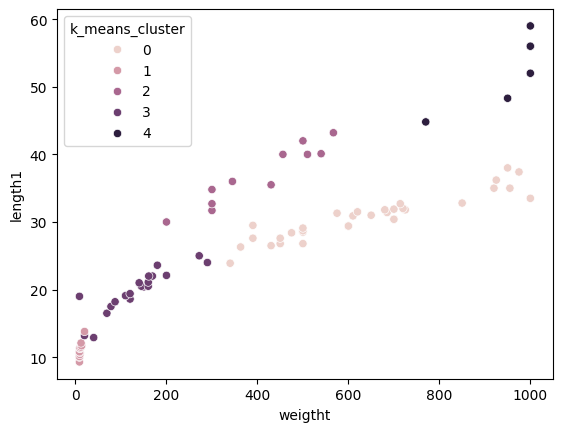

In [ ]:
sns.scatterplot(data=fish,x='weigtht',y='length1',hue='k_means_cluster')

In [ ]:
new_fish=np.array([[40,100,40,50,26,10]])
scaled=scaler.transform(new_fish)
cluster=kmeans.predict(scaled)
cluster

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([4], dtype=int32)

{'icoord': [[15.0, 15.0, 25.0, 25.0],
  [5.0, 5.0, 20.0, 20.0],
  [45.0, 45.0, 55.0, 55.0],
  [65.0, 65.0, 75.0, 75.0],
  [50.0, 50.0, 70.0, 70.0],
  [35.0, 35.0, 60.0, 60.0],
  [85.0, 85.0, 95.0, 95.0],
  [105.0, 105.0, 115.0, 115.0],
  [90.0, 90.0, 110.0, 110.0],
  [125.0, 125.0, 135.0, 135.0],
  [145.0, 145.0, 155.0, 155.0],
  [130.0, 130.0, 150.0, 150.0],
  [175.0, 175.0, 185.0, 185.0],
  [165.0, 165.0, 180.0, 180.0],
  [140.0, 140.0, 172.5, 172.5],
  [100.0, 100.0, 156.25, 156.25],
  [47.5, 47.5, 128.125, 128.125],
  [12.5, 12.5, 87.8125, 87.8125],
  [195.0, 195.0, 205.0, 205.0],
  [215.0, 215.0, 225.0, 225.0],
  [200.0, 200.0, 220.0, 220.0],
  [245.0, 245.0, 255.0, 255.0],
  [235.0, 235.0, 250.0, 250.0],
  [285.0, 285.0, 295.0, 295.0],
  [275.0, 275.0, 290.0, 290.0],
  [265.0, 265.0, 282.5, 282.5],
  [242.5, 242.5, 273.75, 273.75],
  [210.0, 210.0, 258.125, 258.125],
  [305.0, 305.0, 315.0, 315.0],
  [325.0, 325.0, 335.0, 335.0],
  [310.0, 310.0, 330.0, 330.0],
  [234.0625, 234.0

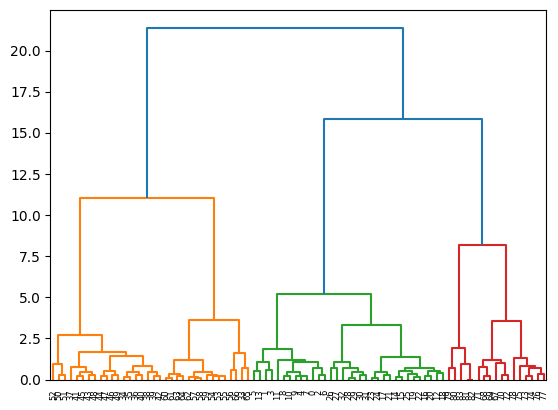

In [ ]:
from scipy.cluster.hierarchy import linkage,dendrogram
mergings=linkage(x_scaled,method='ward')
dendrogram(mergings)


In [ ]:
from sklearn.cluster import AgglomerativeClustering
agg_hc=AgglomerativeClustering(n_clusters=4,metric='euclidean',linkage='ward')
agg_cluster=agg_hc.fit_predict(x_scaled)
agg_cluster

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
data['agg_cluster']=agg_cluster
data.head()

,weigtht,length1,length2,length3,height,width,agg_cluster,db_cluster
0,290.0,24.0,26.3,31.2,40.0,13.8,2,-1
1,340.0,23.9,26.5,31.1,39.8,15.1,2,-1
2,363.0,26.3,29.0,33.5,38.0,13.3,2,-1
3,430.0,26.5,29.0,34.0,36.6,15.1,2,-1
4,450.0,26.8,29.7,34.7,39.2,14.2,2,-1


<Axes: xlabel='length1', ylabel='weigtht'>

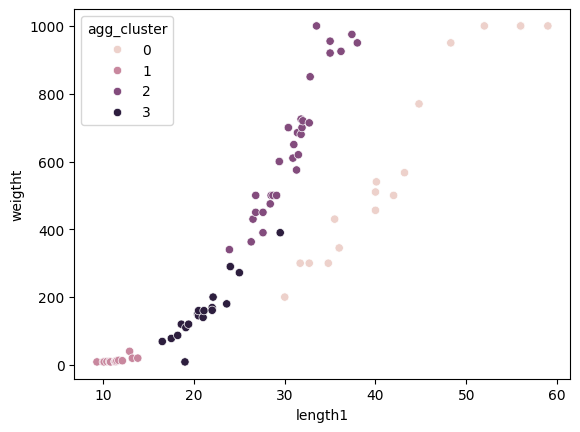

In [ ]:
sns.scatterplot(data=data,x='length1',y='weigtht',hue='agg_cluster')

In [ ]:
sil_scores={}
for i in range(2,11):
  agg_hc=AgglomerativeClustering(n_clusters=5,metric='euclidean',linkage='ward')
  sil_h=silhouette_score(x_scaled,agg_hc.fit_predict(x_scaled))
  sil_scores[i]=(sil_h)
sil_scores


{2: np.float64(0.5810622476833204),
 3: np.float64(0.5810622476833204),
 4: np.float64(0.5810622476833204),
 5: np.float64(0.5810622476833204),
 6: np.float64(0.5810622476833204),
 7: np.float64(0.5810622476833204),
 8: np.float64(0.5810622476833204),
 9: np.float64(0.5810622476833204),
 10: np.float64(0.5810622476833204)}

In [ ]:
from sklearn.cluster import DBSCAN
db = DBSCAN(eps=0.5, min_samples=10)
db_cluster_labels=db.fit_predict(x_scaled)
db_cluster_labels

array([-1, -1, -1, -1, -1, -1, -1, -1,  0,  0,  0, -1,  0, -1,  0,  0,  0,
       -1,  0,  0,  0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1,  1, -1,  1,  1,  1,  1,  1,  1, -1,  1,  1, -1,  1, -1, -1,
       -1, -1,  2,  2,  2, -1,  2,  2,  2,  2,  2,  2,  2,  2, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [ ]:
data['db_cluster']=db_cluster_labels
data.head()

,weigtht,length1,length2,length3,height,width,agg_cluster,db_cluster
0,290.0,24.0,26.3,31.2,40.0,13.8,2,-1
1,340.0,23.9,26.5,31.1,39.8,15.1,2,-1
2,363.0,26.3,29.0,33.5,38.0,13.3,2,-1
3,430.0,26.5,29.0,34.0,36.6,15.1,2,-1
4,450.0,26.8,29.7,34.7,39.2,14.2,2,-1


In [ ]:
data['db_cluster'].value_counts()

,count
db_cluster,
-1,53
2,11
0,10
1,10


<Axes: xlabel='length1', ylabel='weigtht'>

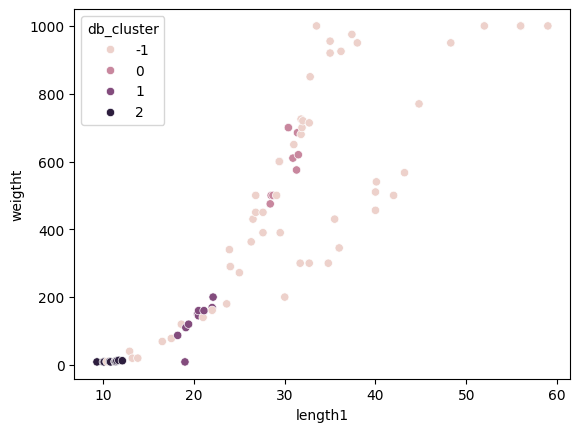

In [ ]:
sns.scatterplot(data=data,x='length1',y='weigtht',hue='db_cluster')

In [ ]:
sil_scores={}
for i in range(2,11):
  db_hc=DBSCAN()
  sil_h=silhouette_score(x_scaled,db_hc.fit_predict(x_scaled))
  sil_scores[i]=(sil_h)
sil_scores


{2: np.float64(0.2911857572826304),
 3: np.float64(0.2911857572826304),
 4: np.float64(0.2911857572826304),
 5: np.float64(0.2911857572826304),
 6: np.float64(0.2911857572826304),
 7: np.float64(0.2911857572826304),
 8: np.float64(0.2911857572826304),
 9: np.float64(0.2911857572826304),
 10: np.float64(0.2911857572826304)}

In [ ]:
from scipy.cluster.hierarchy import fcluster
cluster_labels=fcluster(mergings,criterion='maxclust',t=5)
cluster_labels

array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 4, 4, 4, 4], dtype=int32)